In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [2]:
base_path = '/kaggle/input/datasets/chethuhn/network-intrusion-dataset'

#all csv files
try:
    csv_files = [f for f in os.listdir(base_path) if f.endswith('csv')]
    print(f"Found {len(csv_files)} CSV files:")
    for i, file in enumerate(csv_files,1):
        print(f" {i}.{file}")
except:
    print("The base path for the dataset is not correct.")
    csv_files = []


#load all csv files and combine load a subset first
dfs = []

if csv_files:
    for file in csv_files:
        try:
            df_temp = pd.read_csv(os.path.join(base_path, file), encoding='utf-8')
            dfs.append(df_temp)
            print(f"Loaded {file}: {df_temp.shape}")
        except Exception as e:
            print(f"Error Loading..")

    #combine all dataframes
    data = pd.concat(dfs, ignore_index = True)
    print(f"Total Dataset: {data.shape}")
    print(f"Total Rows: {data.shape[0]:,} | Columns: {data.shape[1]}")

else:
    print("Loading Samples")
    data = pd.DataFrame()


#display first few rows
if not data.empty:
    display(data.head())

Found 8 CSV files:
 1.Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 2.Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 3.Tuesday-WorkingHours.pcap_ISCX.csv
 4.Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 5.Monday-WorkingHours.pcap_ISCX.csv
 6.Friday-WorkingHours-Morning.pcap_ISCX.csv
 7.Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 8.Wednesday-workingHours.pcap_ISCX.csv
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Total Dataset: (2830743, 79)
Total Rows: 2,830,743 | Column

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
categorical = [col for col in data.columns if data[col].dtype == 'object']
print ("Categorical values:", categorical)
numerical = [col for col in data.columns if data[col].dtype != 'object']
print("Numerical values:", numerical)

Categorical values: [' Label']
Numerical values: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', 

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


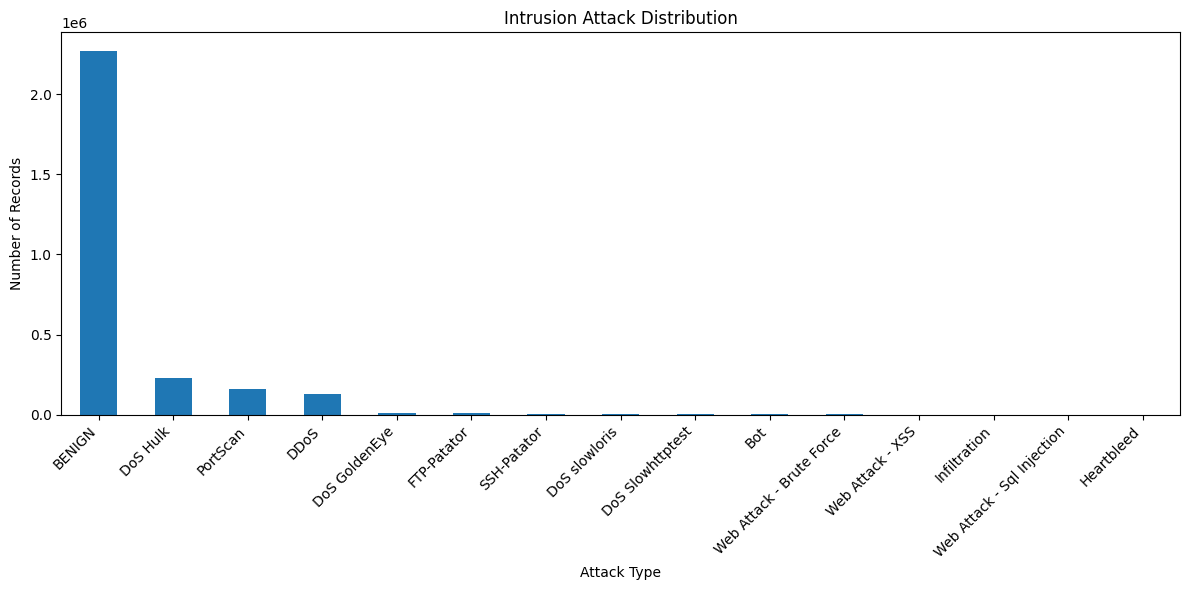

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean column names
data.columns = data.columns.str.strip()

# 2. Clean Label values
data['Label'] = data['Label'].astype(str).str.strip()

# 3. Remove duplicated header rows if they exist
data = data[data['Label'] != 'Label']

# 4. Fix encoding issue if needed
data['Label'] = data['Label'].str.replace('�', '-', regex=False)

# 5. Check class distribution
print(data['Label'].value_counts())

# 6. Plot distribution
plt.figure(figsize=(12, 6))
data['Label'].value_counts().plot(kind='bar')
plt.title("Intrusion Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [6]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print(missing_values)

Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


In [7]:
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    median_value = data[col].median()
    data[col].fillna(median_value, inplace=True)

/tmp/ipykernel_16/927564698.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(median_value, inplace=True)


In [8]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [9]:
print("Shape before dropping duplicates:", data.shape)

data.drop_duplicates(inplace=True)

print("Shape after dropping duplicates:", data.shape)

Shape before dropping duplicates: (2830743, 79)
Shape after dropping duplicates: (2522362, 79)


In [10]:
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()

zero_variance_cols = []

for col in numerical_cols:
    if data[col].nunique() <= 1:
        zero_variance_cols.append(col)

print("Zero-variance columns:", zero_variance_cols)
print("Number of zero-variance columns:", len(zero_variance_cols))

Zero-variance columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Number of zero-variance columns: 8


In [11]:
data.drop(columns=zero_variance_cols, inplace=True)

print("Shape after dropping zero-variance columns:", data.shape)

Shape after dropping zero-variance columns: (2522362, 71)


In [12]:
def optimize_memory_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage before optimization: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != 'object':
            col_min = df[col].min()
            col_max = df[col].max()
            
            if str(col_type).startswith('int'):
                if col_min >= 0:
                    if col_max <= np.iinfo(np.uint8).max:
                        df[col] = df[col].astype(np.uint8)
                    elif col_max <= np.iinfo(np.uint16).max:
                        df[col] = df[col].astype(np.uint16)
                    elif col_max <= np.iinfo(np.uint32).max:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if col_min >= np.iinfo(np.int8).min and col_max <= np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif col_min >= np.iinfo(np.int16).min and col_max <= np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif col_min >= np.iinfo(np.int32).min and col_max <= np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    else:
                        df[col] = df[col].astype(np.int64)
            
            elif str(col_type).startswith('float'):
                df[col] = pd.to_numeric(df[col], downcast='float')
    
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage after optimization: {end_mem:.2f} MB")
    print(f"Memory reduced by: {100 * (start_mem - end_mem) / start_mem:.2f}%")
    
    return df

In [13]:
data = optimize_memory_usage(data)

Memory usage before optimization: 1499.12 MB
Memory usage after optimization: 876.09 MB
Memory reduced by: 41.56%


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2522362 entries, 0 to 2830742
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             uint16 
 1   Flow Duration                int32  
 2   Total Fwd Packets            uint32 
 3   Total Backward Packets       uint32 
 4   Total Length of Fwd Packets  uint32 
 5   Total Length of Bwd Packets  uint32 
 6   Fwd Packet Length Max        uint16 
 7   Fwd Packet Length Min        uint16 
 8   Fwd Packet Length Mean       float32
 9   Fwd Packet Length Std        float32
 10  Bwd Packet Length Max        uint16 
 11  Bwd Packet Length Min        uint16 
 12  Bwd Packet Length Mean       float32
 13  Bwd Packet Length Std        float32
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int32  
 19  Flow 

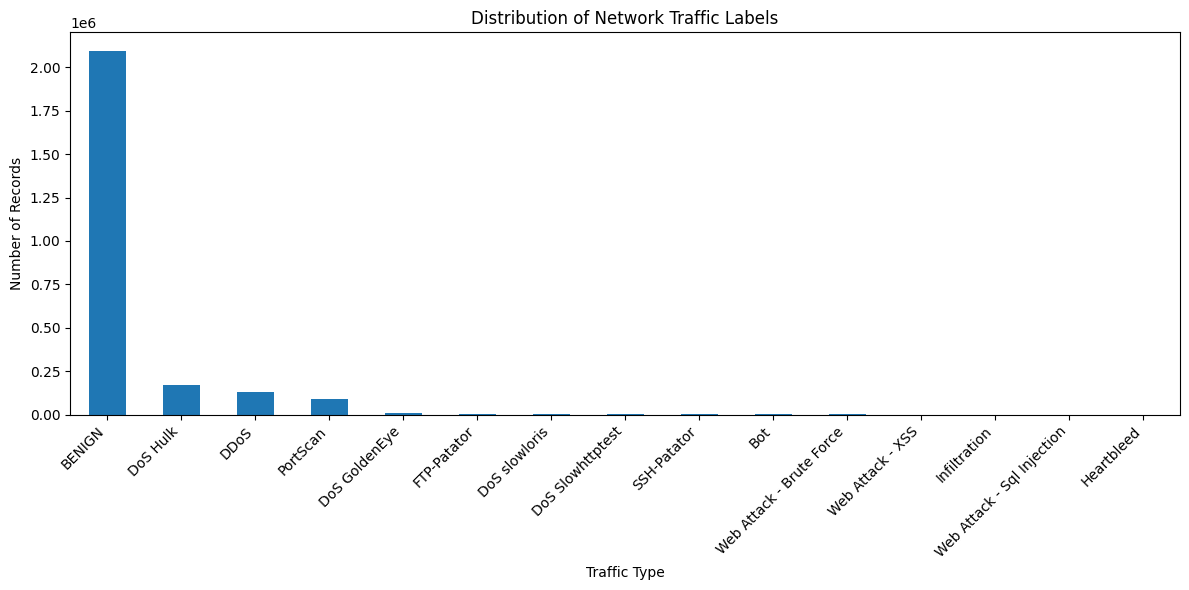

In [15]:
plt.figure(figsize=(12, 6))

data['Label'].value_counts().plot(kind='bar')

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

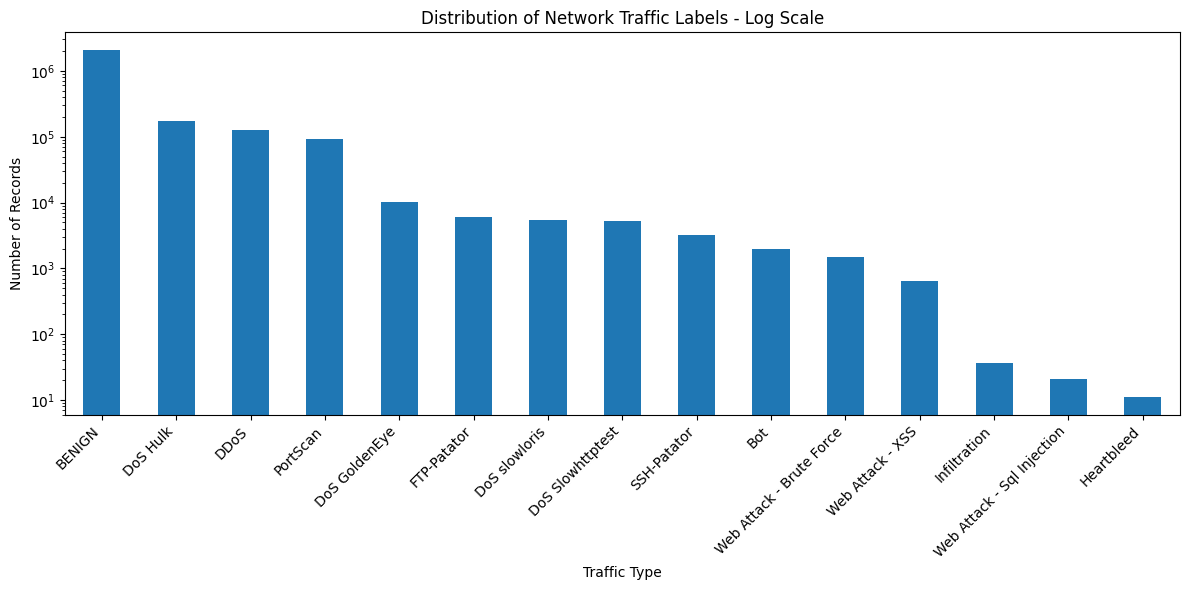

In [16]:
plt.figure(figsize=(12, 6))

data['Label'].value_counts().plot(kind='bar')

plt.title("Distribution of Network Traffic Labels - Log Scale")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
correlation_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'URG Flag Count'
]

available_features = [col for col in correlation_features if col in data.columns]

print("Available features for heatmap:", available_features)

Available features for heatmap: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count', 'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'URG Flag Count']


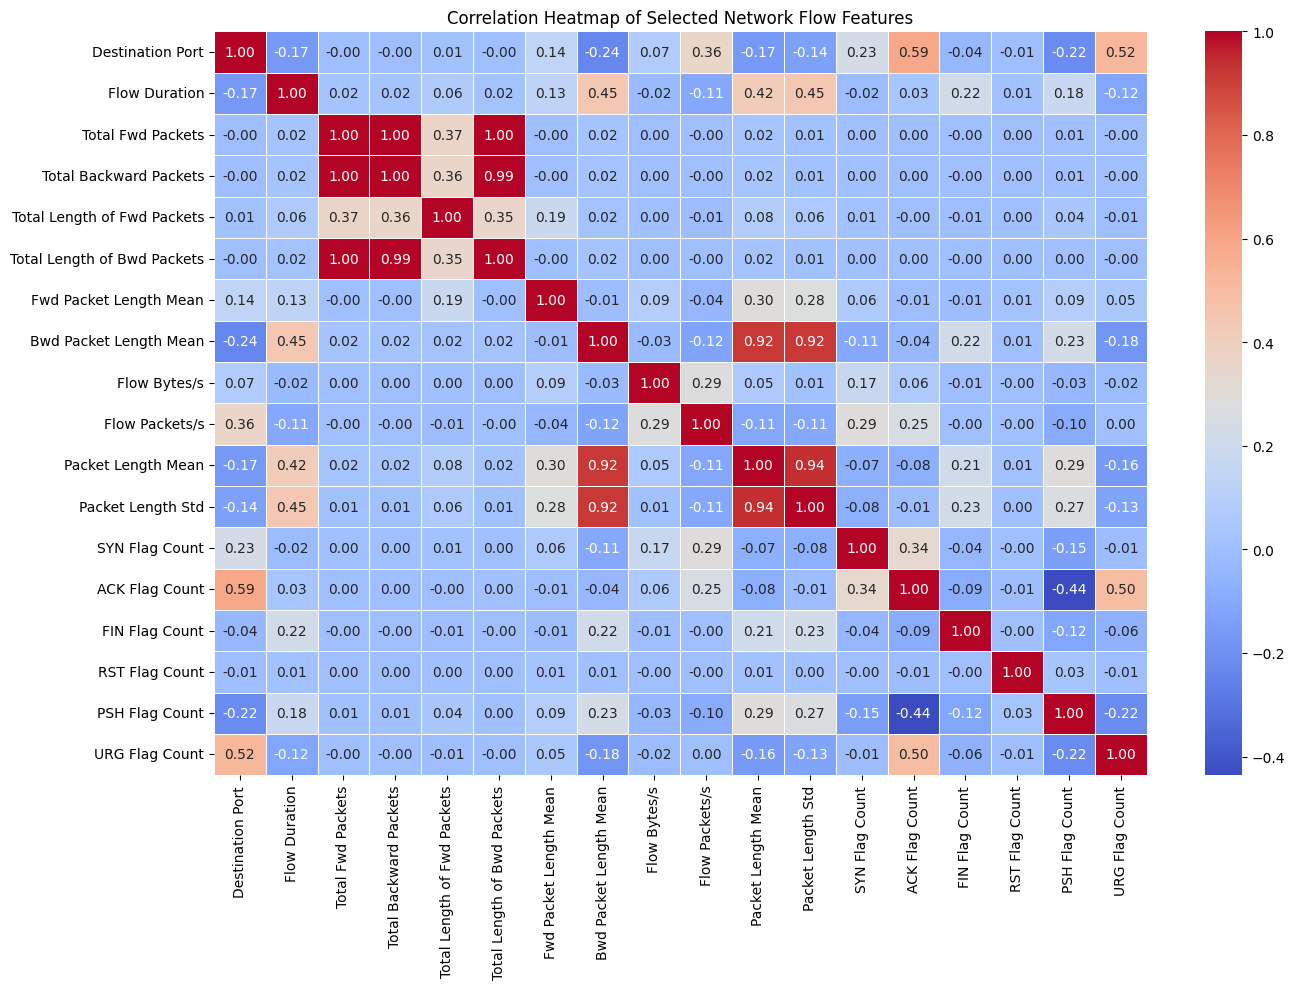

In [18]:
import seaborn as sns
plt.figure(figsize=(14, 10))

corr_matrix = data[available_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Selected Network Flow Features")
plt.tight_layout()
plt.show()

In [19]:
print("Final dataset shape:", data.shape)
print("Total missing values:", data.isnull().sum().sum())
print("Duplicate rows:", data.duplicated().sum())
print("Number of columns:", len(data.columns))
print("Label distribution:")
print(data['Label'].value_counts())

Final dataset shape: (2522362, 71)
Total missing values: 0
Duplicate rows: 6
Number of columns: 71
Label distribution:
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [21]:
!pip install imbalanced-learn

In [22]:
# Make sure column names are clean
data.columns = data.columns.str.strip()

# Clean Label values
data['Label'] = data['Label'].astype(str).str.strip()

# Encode Label
label_encoder = LabelEncoder()
data['Label_encoded'] = label_encoder.fit_transform(data['Label'])

# Show label mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Mapping:")
for label, encoded in label_mapping.items():
    print(f"{label}: {encoded}")

Label Mapping:
BENIGN: 0
Bot: 1
DDoS: 2
DoS GoldenEye: 3
DoS Hulk: 4
DoS Slowhttptest: 5
DoS slowloris: 6
FTP-Patator: 7
Heartbleed: 8
Infiltration: 9
PortScan: 10
SSH-Patator: 11
Web Attack - Brute Force: 12
Web Attack - Sql Injection: 13
Web Attack - XSS: 14


In [23]:
selected_features = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Packet Length Mean',
    'Packet Length Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'URG Flag Count'
]

# Check missing columns
missing_cols = [col for col in selected_features if col not in data.columns]
print("Missing columns:", missing_cols)

# Create X and y
X = data[selected_features]
y = data['Label_encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)

Missing columns: []
X shape: (2522362, 18)
y shape: (2522362,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("Original training label distribution:")
print(Counter(y_train))

Training set shape: (2017889, 18)
Testing set shape: (504473, 18)
Original training label distribution:
Counter({0: 1677187, 4: 138279, 2: 102413, 10: 72655, 3: 8229, 7: 4746, 6: 4308, 5: 4182, 11: 2575, 1: 1562, 12: 1176, 14: 522, 9: 29, 13: 17, 8: 9})


In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [26]:
# Find encoded value of BENIGN
benign_encoded = label_encoder.transform(['BENIGN'])[0]

class_counts = Counter(y_train)
benign_count = class_counts[benign_encoded]

# Minority target = 10% of BENIGN class
target_minority_count = int(0.1 * benign_count)

print("BENIGN encoded value:", benign_encoded)
print("BENIGN count:", benign_count)
print("Target minority count:", target_minority_count)

BENIGN encoded value: 0
BENIGN count: 1677187
Target minority count: 167718


In [27]:
smote_strategy = {}

for class_label, count in class_counts.items():
    if class_label != benign_encoded and count < target_minority_count:
        smote_strategy[class_label] = target_minority_count

print("SMOTE strategy:")
print(smote_strategy)

SMOTE strategy:
{4: 167718, 10: 167718, 2: 167718, 12: 167718, 3: 167718, 7: 167718, 1: 167718, 5: 167718, 14: 167718, 6: 167718, 11: 167718, 8: 167718, 9: 167718, 13: 167718}


In [28]:
smote = SMOTE(
    sampling_strategy=smote_strategy,
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print(Counter(y_train_smote))

After SMOTE:
Counter({0: 1677187, 4: 167718, 10: 167718, 2: 167718, 12: 167718, 3: 167718, 7: 167718, 1: 167718, 5: 167718, 14: 167718, 6: 167718, 11: 167718, 8: 167718, 9: 167718, 13: 167718})


In [29]:
after_smote_counts = Counter(y_train_smote)

benign_under_count = target_minority_count * 3

under_strategy = {}

for class_label, count in after_smote_counts.items():
    if class_label == benign_encoded:
        under_strategy[class_label] = min(count, benign_under_count)
    else:
        under_strategy[class_label] = count

print("RandomUnderSampler strategy:")
print(under_strategy)

RandomUnderSampler strategy:
{4: 167718, 0: 503154, 10: 167718, 2: 167718, 12: 167718, 3: 167718, 7: 167718, 1: 167718, 5: 167718, 14: 167718, 6: 167718, 11: 167718, 8: 167718, 9: 167718, 13: 167718}


In [30]:
under_sampler = RandomUnderSampler(
    sampling_strategy=under_strategy,
    random_state=42
)

X_train_resampled, y_train_resampled = under_sampler.fit_resample(
    X_train_smote,
    y_train_smote
)

print("After SMOTE + RandomUnderSampler:")
print(Counter(y_train_resampled))

After SMOTE + RandomUnderSampler:
Counter({0: 503154, 1: 167718, 2: 167718, 3: 167718, 4: 167718, 5: 167718, 6: 167718, 7: 167718, 8: 167718, 9: 167718, 10: 167718, 11: 167718, 12: 167718, 13: 167718, 14: 167718})


In [31]:
before_balance = pd.Series(y_train).map(
    dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
).value_counts()

after_balance = pd.Series(y_train_resampled).map(
    dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
).value_counts()

print("Before balancing:")
print(before_balance)

print("\nAfter balancing:")
print(after_balance)

Before balancing:
Label_encoded
BENIGN                        1677187
DoS Hulk                       138279
DDoS                           102413
PortScan                        72655
DoS GoldenEye                    8229
FTP-Patator                      4746
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1562
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - Sql Injection         17
Heartbleed                          9
Name: count, dtype: int64

After balancing:
Label_encoded
BENIGN                        503154
Bot                           167718
DDoS                          167718
DoS GoldenEye                 167718
DoS Hulk                      167718
DoS Slowhttptest              167718
DoS slowloris                 167718
FTP-Patator                   167718
Heartbleed                    167718
Infiltr

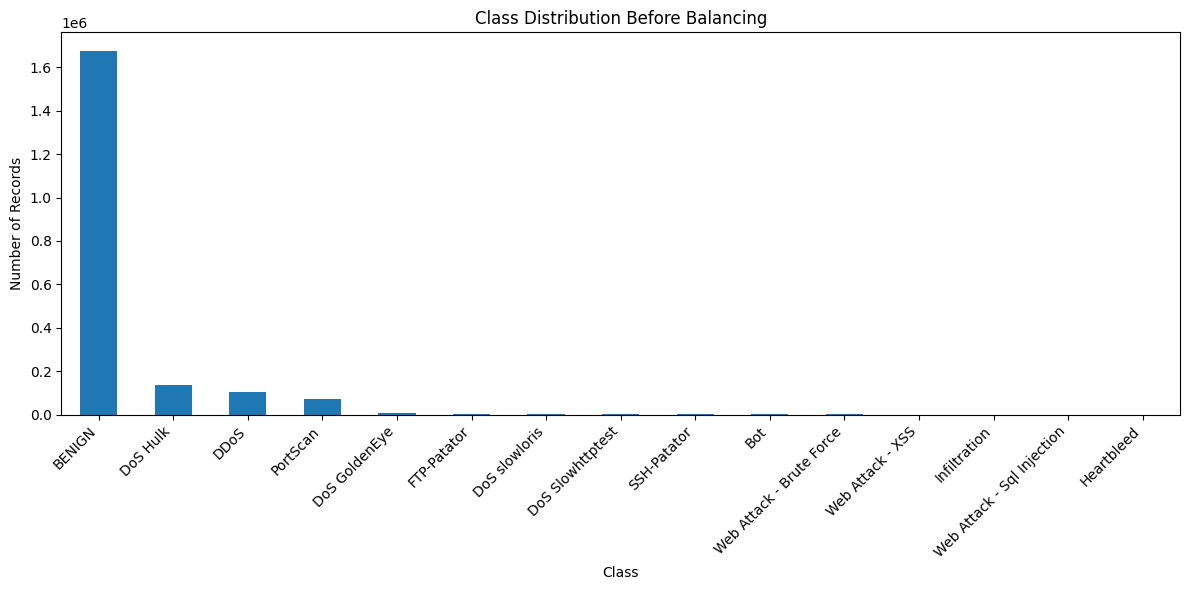

In [32]:
plt.figure(figsize=(12, 6))
before_balance.plot(kind='bar')
plt.title("Class Distribution Before Balancing")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

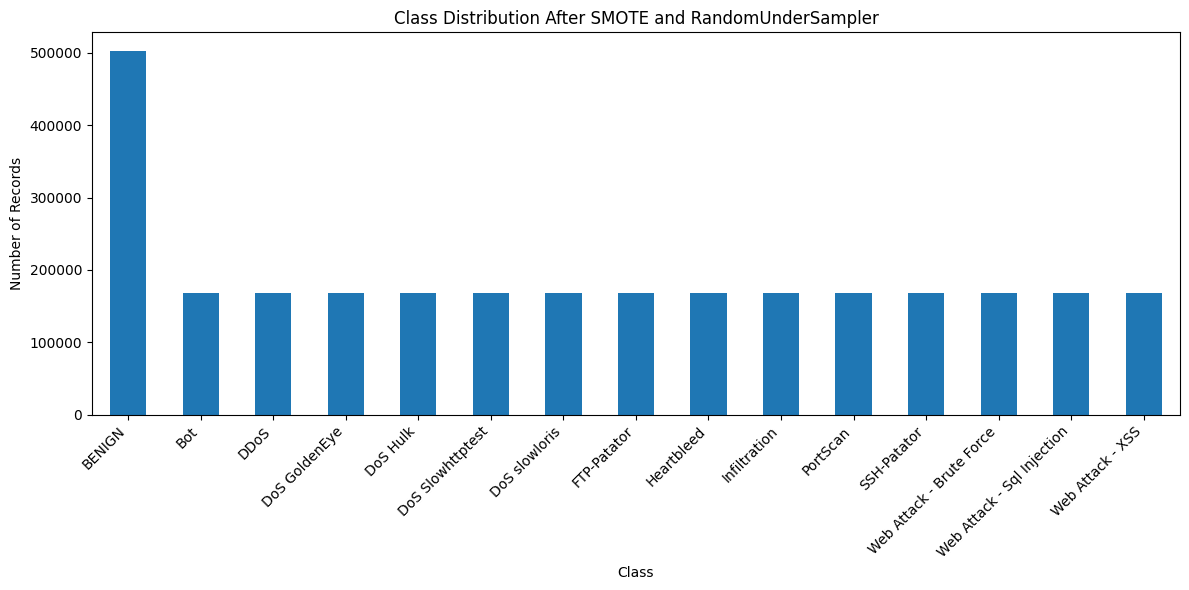

In [33]:
plt.figure(figsize=(12, 6))
after_balance.plot(kind='bar')
plt.title("Class Distribution After SMOTE and RandomUnderSampler")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt
import time

# ===============================
# Bernoulli Naive Bayes Model
# ===============================

print("Training Bernoulli Naive Bayes...")

start_time = time.time()

bnb_model = BernoulliNB()

# Train model using balanced training data
bnb_model.fit(X_train_resampled, y_train_resampled)

train_time_bnb = time.time() - start_time

# ===============================
# Prediction
# ===============================

y_pred_bnb = bnb_model.predict(X_test_scaled)

# ===============================
# Evaluation Metrics
# ===============================

accuracy_bnb = accuracy_score(y_test, y_pred_bnb)

precision_bnb = precision_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)

recall_bnb = recall_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)

f1_bnb = f1_score(
    y_test,
    y_pred_bnb,
    average='weighted',
    zero_division=0
)

print("Bernoulli Naive Bayes Results")
print("-----------------------------")
print(f"Accuracy:  {accuracy_bnb:.4f}")
print(f"Precision: {precision_bnb:.4f}")
print(f"Recall:    {recall_bnb:.4f}")
print(f"F1 Score:  {f1_bnb:.4f}")
print(f"Training Time: {train_time_bnb:.2f} seconds")

Training Bernoulli Naive Bayes...
Bernoulli Naive Bayes Results
-----------------------------
Accuracy:  0.5951
Precision: 0.9130
Recall:    0.5951
F1 Score:  0.7011
Training Time: 1.60 seconds


In [35]:
# ===============================
# Classification Report
# ===============================

print("Classification Report - Bernoulli Naive Bayes")
print(
    classification_report(
        y_test,
        y_pred_bnb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Bernoulli Naive Bayes
                            precision    recall  f1-score   support

                    BENIGN       0.95      0.61      0.75    419297
                       Bot       0.00      0.37      0.01       391
                      DDoS       0.80      0.01      0.03     25603
             DoS GoldenEye       0.03      0.71      0.06      2057
                  DoS Hulk       0.86      0.81      0.84     34570
          DoS Slowhttptest       0.07      0.72      0.12      1046
             DoS slowloris       0.07      0.58      0.12      1077
               FTP-Patator       0.18      0.98      0.31      1187
                Heartbleed       0.00      1.00      0.00         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.63      0.50      0.56     18164
               SSH-Patator       0.18      0.91      0.31       644
  Web Attack - Brute Force       0.00      0.05      0.00       294
W

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ===============================
# Random Forest Model
# ===============================

print("Training Random Forest...")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=2,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

train_time_rf = time.time() - start_time

# ===============================
# Prediction
# ===============================

y_pred_rf = rf_model.predict(X_test_scaled)

# ===============================
# Evaluation Metrics
# ===============================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")
print(f"Training Time: {train_time_rf:.2f} seconds")

Training Random Forest...
Random Forest Results
---------------------
Accuracy:  0.9912
Precision: 0.9968
Recall:    0.9912
F1 Score:  0.9938
Training Time: 644.60 seconds


In [37]:
print("Classification Report - Random Forest")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Random Forest
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    419297
                       Bot       0.37      0.85      0.51       391
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.96      0.99      0.98      2057
                  DoS Hulk       0.99      1.00      0.99     34570
          DoS Slowhttptest       0.98      0.99      0.98      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      1.00      0.99     18164
               SSH-Patator       0.92      0.99      0.95       644
  Web Attack - Brute Force       0.11      0.57      0.18       294
Web Attac

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ===============================
# K-Nearest Neighbors Model
# ===============================

print("Training K-Nearest Neighbors...")

start_time = time.time()

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model.fit(X_train_resampled, y_train_resampled)

train_time_knn = time.time() - start_time

# ===============================
# Prediction
# ===============================

y_pred_knn = knn_model.predict(X_test_scaled)

# ===============================
# Evaluation Metrics
# ===============================

accuracy_knn = accuracy_score(y_test, y_pred_knn)

precision_knn = precision_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average='weighted',
    zero_division=0
)

print("K-Nearest Neighbors Results")
print("---------------------------")
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1 Score:  {f1_knn:.4f}")
print(f"Training Time: {train_time_knn:.2f} seconds")

Training K-Nearest Neighbors...
K-Nearest Neighbors Results
---------------------------
Accuracy:  0.9791
Precision: 0.9895
Recall:    0.9791
F1 Score:  0.9835
Training Time: 0.15 seconds


In [39]:
print("Classification Report - K-Nearest Neighbors")
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - K-Nearest Neighbors
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    419297
                       Bot       0.18      0.92      0.30       391
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.86      0.99      0.92      2057
                  DoS Hulk       0.99      0.99      0.99     34570
          DoS Slowhttptest       0.92      0.99      0.95      1046
             DoS slowloris       0.91      0.99      0.95      1077
               FTP-Patator       0.99      0.99      0.99      1187
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.08      0.86      0.14         7
                  PortScan       0.82      0.99      0.90     18164
               SSH-Patator       0.73      0.99      0.84       644
  Web Attack - Brute Force       0.09      0.53      0.16       294
Web

In [40]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ===============================
# Fast Linear SVM Model
# ===============================

print("Training Fast Linear SVM...")

start_time = time.time()

svm_model = LinearSVC(
    random_state=42,
    max_iter=100,
    dual=False,      # thường nhanh hơn khi số samples > số features
    C=1.0
)

svm_model.fit(X_train_resampled, y_train_resampled)

train_time_svm = time.time() - start_time

# ===============================
# Prediction
# ===============================

y_pred_svm = svm_model.predict(X_test_scaled)

# ===============================
# Evaluation Metrics
# ===============================

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='weighted',
    zero_division=0
)

print("Fast Linear SVM Results")
print("-----------------------")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1 Score:  {f1_svm:.4f}")
print(f"Training Time: {train_time_svm:.2f} seconds")

Training Fast Linear SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fast Linear SVM Results
-----------------------
Accuracy:  0.7727
Precision: 0.9465
Recall:    0.7727
F1 Score:  0.8374
Training Time: 1356.57 seconds


In [41]:
print("Classification Report - SVM")
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - SVM
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.74      0.85    419297
                       Bot       0.02      0.49      0.03       391
                      DDoS       0.57      0.98      0.72     25603
             DoS GoldenEye       0.32      0.66      0.43      2057
                  DoS Hulk       0.89      0.90      0.89     34570
          DoS Slowhttptest       0.34      0.79      0.48      1046
             DoS slowloris       0.05      0.56      0.09      1077
               FTP-Patator       0.17      0.99      0.28      1187
                Heartbleed       0.50      1.00      0.67         2
              Infiltration       0.00      0.86      0.00         7
                  PortScan       0.67      0.99      0.80     18164
               SSH-Patator       0.07      0.92      0.13       644
  Web Attack - Brute Force       0.02      0.05      0.02       294
Web Attack - Sql In

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time

# ===============================
# Logistic Regression Model
# ===============================

print("Training Logistic Regression...")

start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    solver='saga'
)

lr_model.fit(X_train_resampled, y_train_resampled)

train_time_lr = time.time() - start_time

# ===============================
# Prediction
# ===============================

y_pred_lr = lr_model.predict(X_test_scaled)

# ===============================
# Evaluation Metrics
# ===============================

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average='weighted',
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average='weighted',
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='weighted',
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")
print(f"Training Time: {train_time_lr:.2f} seconds")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression Results
---------------------------
Accuracy:  0.7625
Precision: 0.9492
Recall:    0.7625
F1 Score:  0.8314
Training Time: 5889.26 seconds


In [43]:
print("Classification Report - Logistic Regression")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Logistic Regression
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.72      0.84    419297
                       Bot       0.01      0.53      0.02       391
                      DDoS       0.59      0.99      0.74     25603
             DoS GoldenEye       0.32      0.83      0.46      2057
                  DoS Hulk       0.90      0.94      0.92     34570
          DoS Slowhttptest       0.07      0.80      0.12      1046
             DoS slowloris       0.25      0.57      0.35      1077
               FTP-Patator       0.17      0.99      0.29      1187
                Heartbleed       0.15      1.00      0.27         2
              Infiltration       0.00      0.71      0.01         7
                  PortScan       0.69      0.98      0.81     18164
               SSH-Patator       0.07      0.92      0.12       644
  Web Attack - Brute Force       0.00      0.05      0.01       294
Web

In [44]:
from tabulate import tabulate

comparison_data = [
    ["Logistic Regression", accuracy_lr, precision_lr, recall_lr, f1_lr],
    ["Bernoulli Naive Bayes", accuracy_bnb, precision_bnb, recall_bnb, f1_bnb],
    ["K-Nearest Neighbors", accuracy_knn, precision_knn, recall_knn, f1_knn],
    ["SVM / Linear SVM", accuracy_svm, precision_svm, recall_svm, f1_svm],
    ["Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf],
]

col_names = ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]

print(
    tabulate(
        comparison_data,
        headers=col_names,
        tablefmt="fancy_grid",
        floatfmt=".4f"
    )
)

╒═══════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model                 │   Accuracy │   Precision │   Recall │   F1 Score │
╞═══════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│ Logistic Regression   │     0.7625 │      0.9492 │   0.7625 │     0.8314 │
├───────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Bernoulli Naive Bayes │     0.5951 │      0.9130 │   0.5951 │     0.7011 │
├───────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ K-Nearest Neighbors   │     0.9791 │      0.9895 │   0.9791 │     0.9835 │
├───────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ SVM / Linear SVM      │     0.7727 │      0.9465 │   0.7727 │     0.8374 │
├───────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│ Random Forest         │     0.9912 │      0.9968 │   0.9912 │     0.9938 │
╘═══════════════════════╧════════════╧═════════════╧══════════╧════════════╛

In [45]:
import joblib
import os

# Create folder to store saved models
os.makedirs("models", exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, "models/random_forest_best_model.pkl")

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save label encoder
joblib.dump(label_encoder, "models/label_encoder.pkl")

# Save selected features
joblib.dump(selected_features, "models/selected_features.pkl")

print("Best Random Forest model and preprocessing objects saved successfully!")

Best Random Forest model and preprocessing objects saved successfully!
